In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


 # Netflix Movies & TV Shows — EDA & Insights Report
     **Author:** Aditya Tiwari | MCA Student
     **Dataset:** Netflix Movies & TV Shows (Kaggle)
     **Tools:** Python, Pandas, Matplotlib, Seaborn

In [ ]:
# CELL 1 — IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries ready")


Libraries ready


In [ ]:
# CELL 2 — LOAD DATA
df = pd.read_csv('netflix_titles.csv')
print("Shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

Shape: (8807, 12)
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# CELL 3 — CLEAN DATA
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df = df.dropna(subset=['rating', 'date_added'])
df['date_added']  = pd.to_datetime(df['date_added'], errors='coerce')
df = df.dropna(subset=['date_added'])
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_mins'] = pd.to_numeric(df_movies['duration'].str.replace(' min','').str.strip(), errors='coerce')
df_movies = df_movies.dropna(subset=['duration_mins'])
df_movies['duration_mins'] = df_movies['duration_mins'].astype(int)
print("Cleaned shape:", df.shape)

Cleaned shape: (8793, 14)


In [ ]:
# CELL 4 — EDA Q1: Movies vs TV Shows
print(df['type'].value_counts())
print(df['type'].value_counts(normalize=True).mul(100).round(1))

type
Movie      6129
TV Show    2664
Name: count, dtype: int64
type
Movie      69.7
TV Show    30.3
Name: proportion, dtype: float64


In [ ]:
# CELL 5 — EDA Q2: Top Countries
top_countries = df['country'].str.split(',').str[0].str.strip().value_counts().head(10)
print(top_countries)

country
United States     3205
India             1008
Unknown            829
United Kingdom     627
Canada             271
Japan              257
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64


In [ ]:
# CELL 6 — EDA Q3: Content Added Per Year
yearly = df.groupby(['year_added','type']).size().unstack(fill_value=0)
print(yearly[yearly.index >= 2010])

type        Movie  TV Show
year_added                
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      175
2017          837      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505


In [ ]:
# CELL 7 — EDA Q4: Ratings
print(df['rating'].value_counts())


rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [ ]:
# CELL 8 — EDA Q5: Top Genres
genres = df['listed_in'].str.split(', ').explode()
print(genres.value_counts().head(15))


listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  573
Crime TV Shows               469
Kids' TV                     448
Docuseries                   394
Name: count, dtype: int64


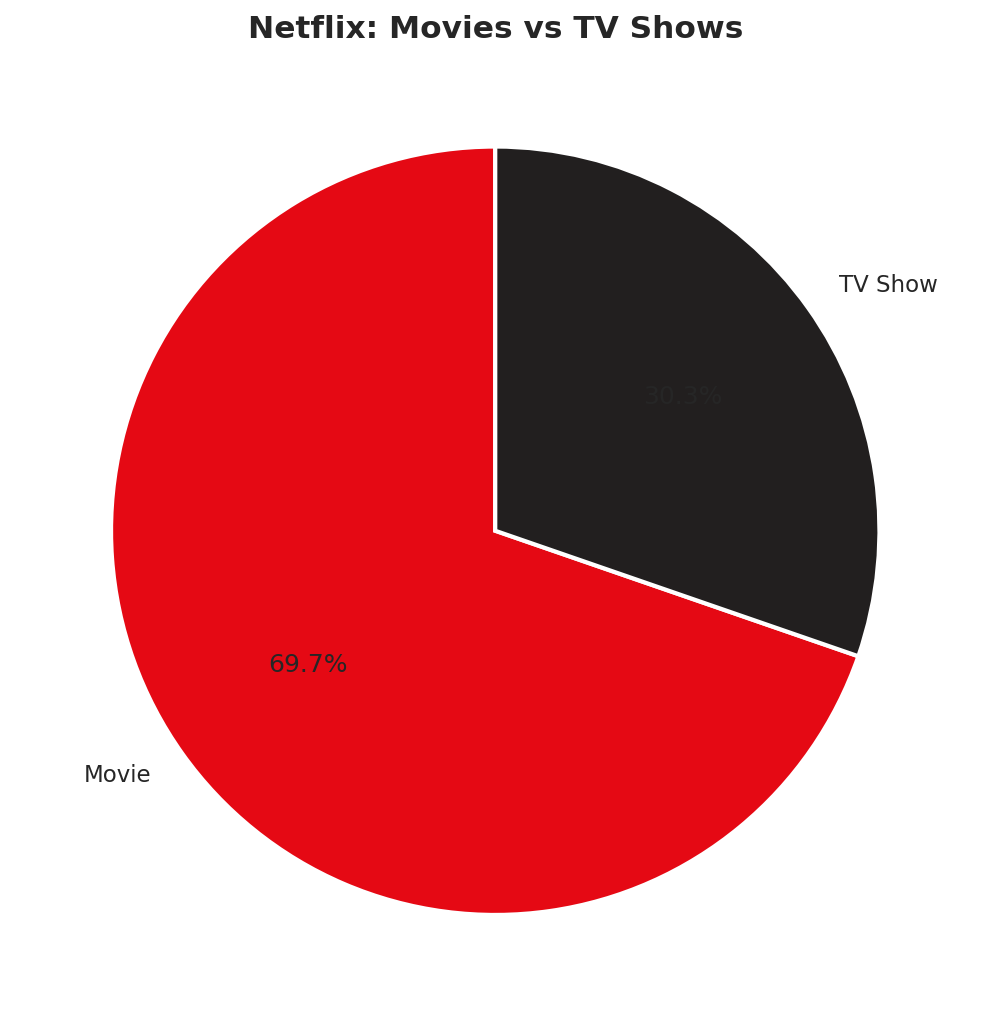

In [ ]:
# CELL 9 — CHART 1: Pie — Movies vs TV Shows
fig, ax = plt.subplots(figsize=(7,7))
counts = df['type'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=['#E50914','#221F1F'], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Netflix: Movies vs TV Shows', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_pie.png', dpi=150, bbox_inches='tight')
plt.show()

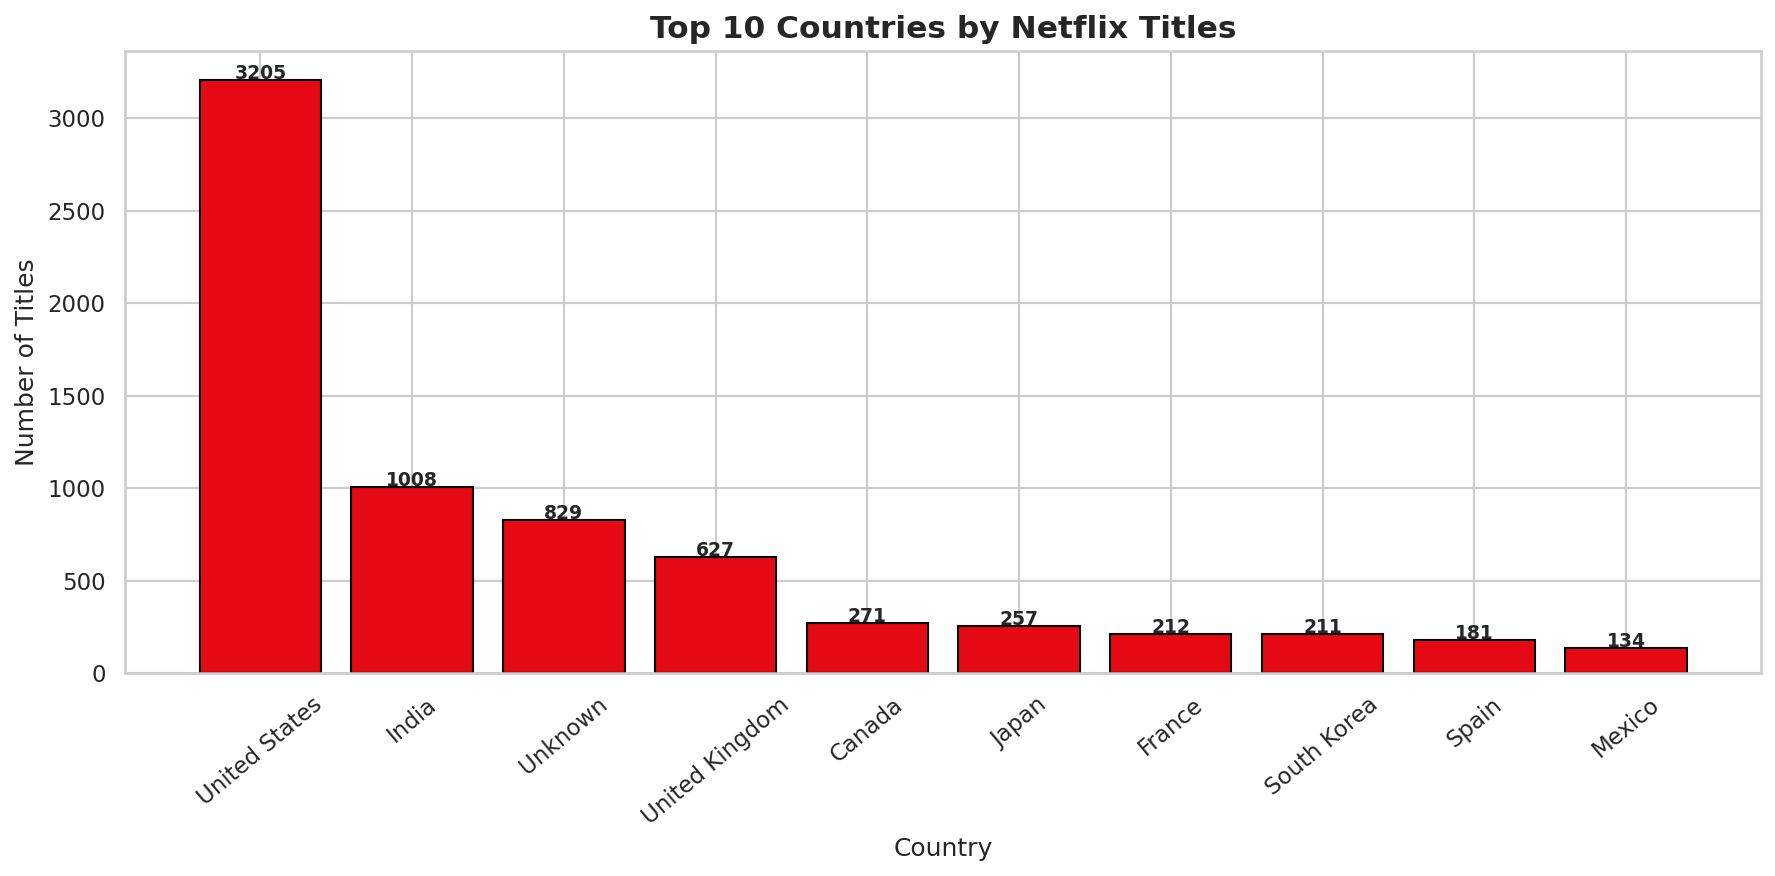

In [ ]:
# CELL 10 — CHART 2: Bar — Top 10 Countries
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(top_countries.index, top_countries.values, color='#E50914', edgecolor='black')
ax.set_title('Top 10 Countries by Netflix Titles', fontsize=15, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Number of Titles')
plt.xticks(rotation=40)
for i,(v) in enumerate(top_countries.values):
    ax.text(i, v+5, str(v), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_bar_countries.png', dpi=150, bbox_inches='tight')
plt.show()


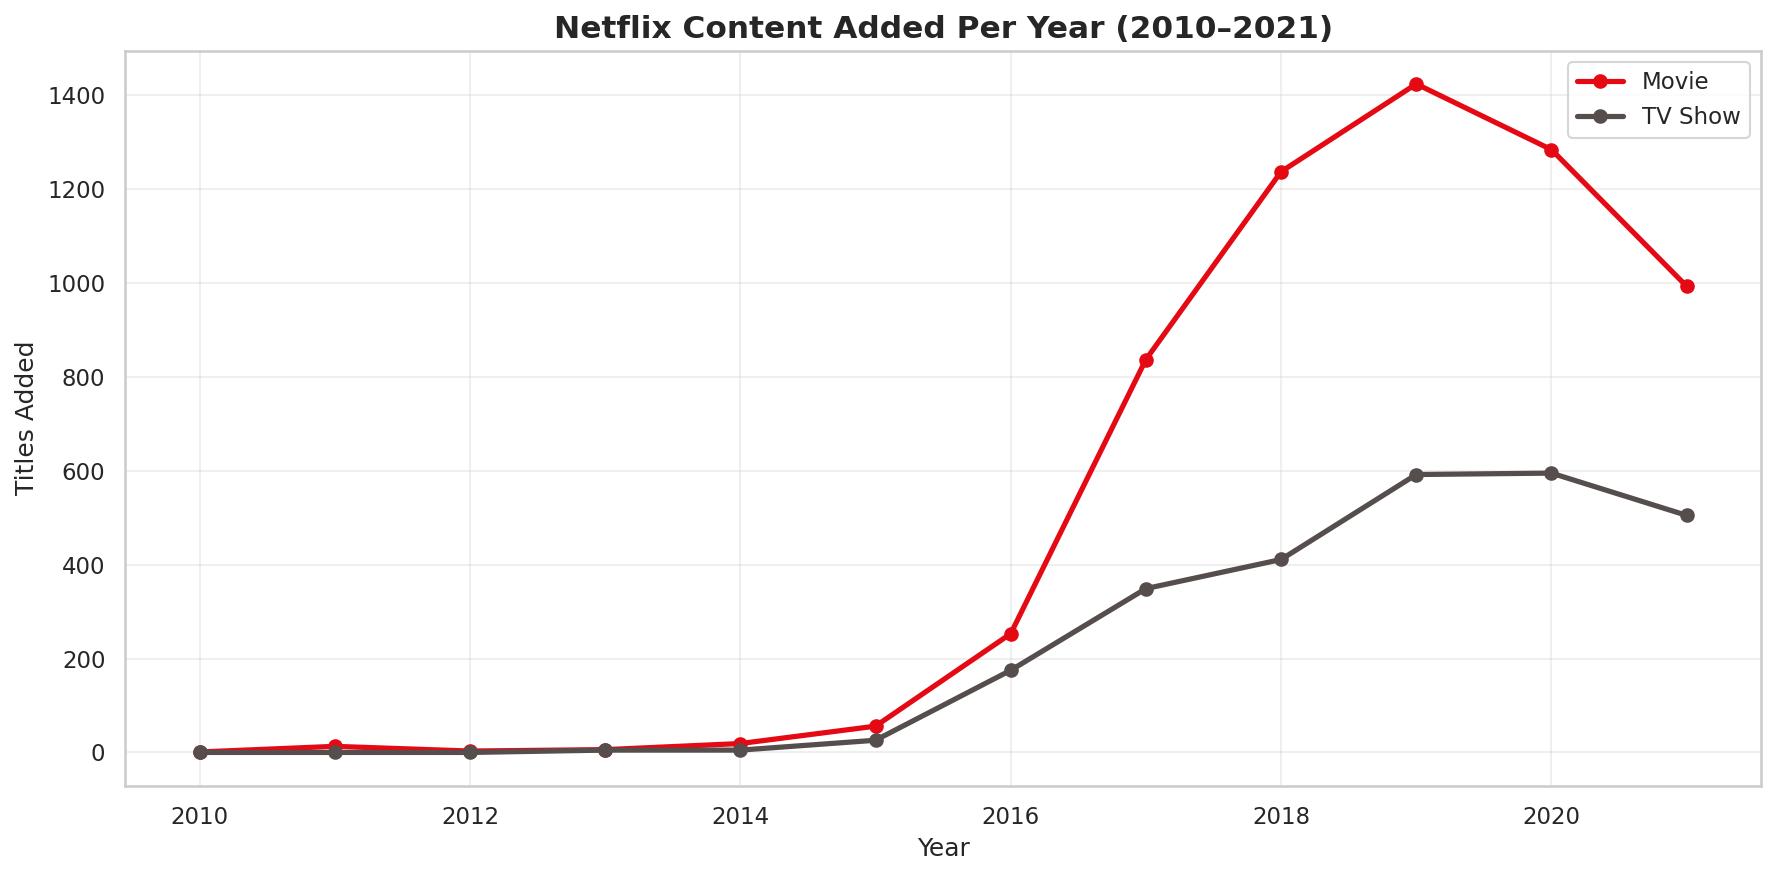

In [ ]:
# CELL 11 — CHART 3: Line — Yearly Growth
fig, ax = plt.subplots(figsize=(12,6))
yearly_f = yearly[yearly.index >= 2010]
for col, color in zip(yearly_f.columns, ['#E50914','#564d4d']):
    ax.plot(yearly_f.index, yearly_f[col], marker='o', linewidth=2.5,
            label=col, color=color, markersize=6)
ax.set_title('Netflix Content Added Per Year (2010–2021)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Titles Added')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_line_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

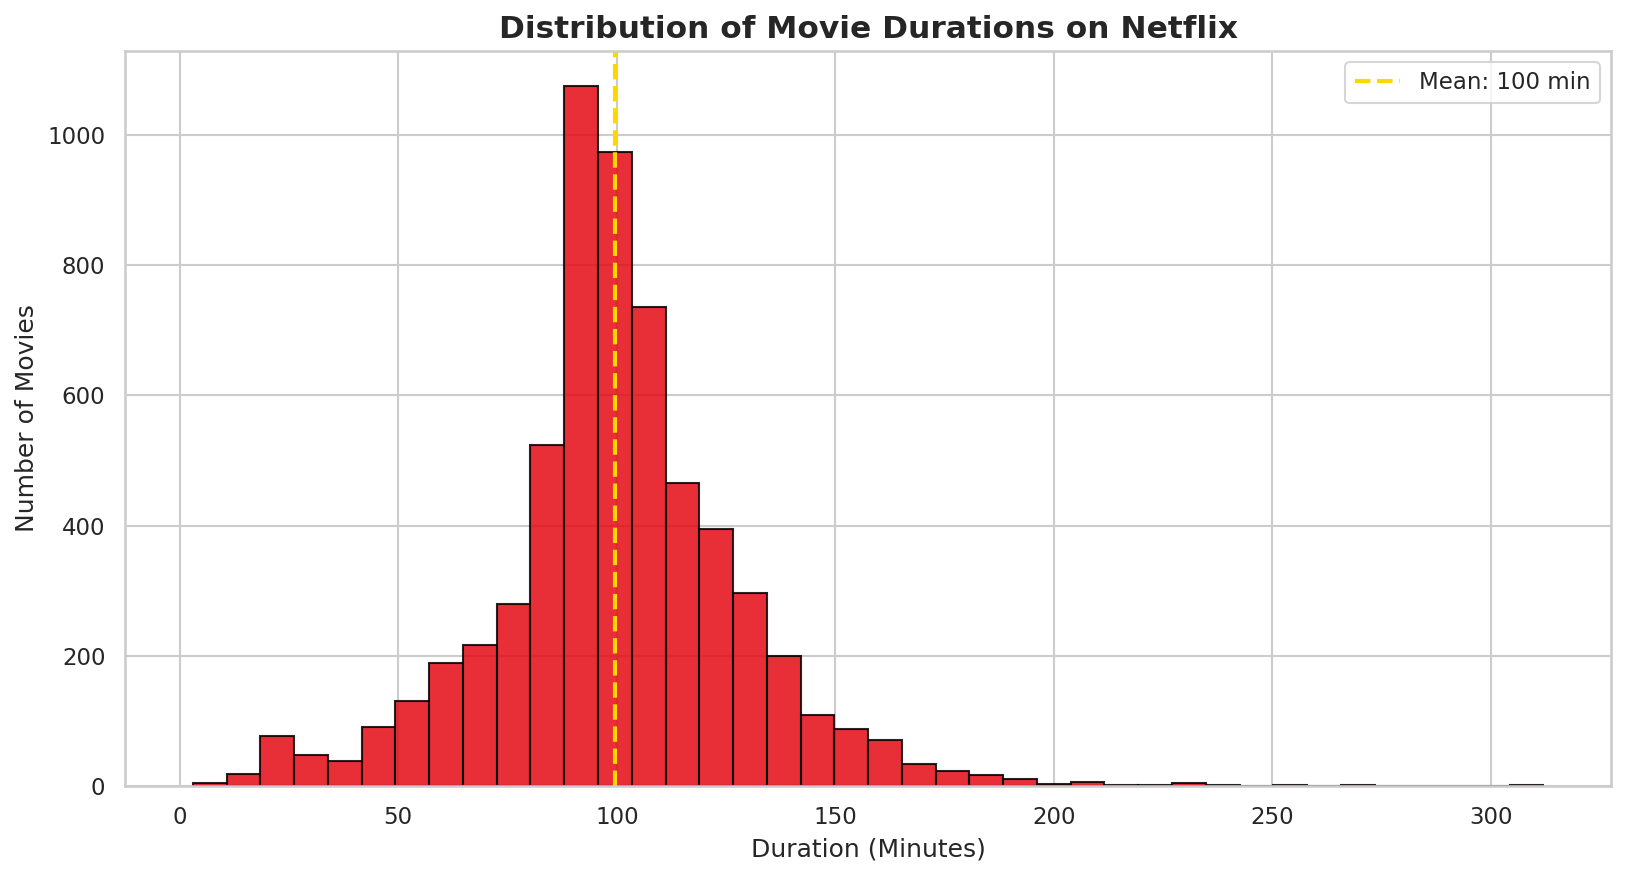

In [ ]:
# CELL 12 — CHART 4: Histogram — Movie Duration
fig, ax = plt.subplots(figsize=(11,6))
ax.hist(df_movies['duration_mins'], bins=40, color='#E50914', edgecolor='black', alpha=0.85)
ax.axvline(df_movies['duration_mins'].mean(), color='gold', linewidth=2,
           linestyle='--', label=f"Mean: {df_movies['duration_mins'].mean():.0f} min")
ax.set_title('Distribution of Movie Durations on Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Duration (Minutes)'); ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

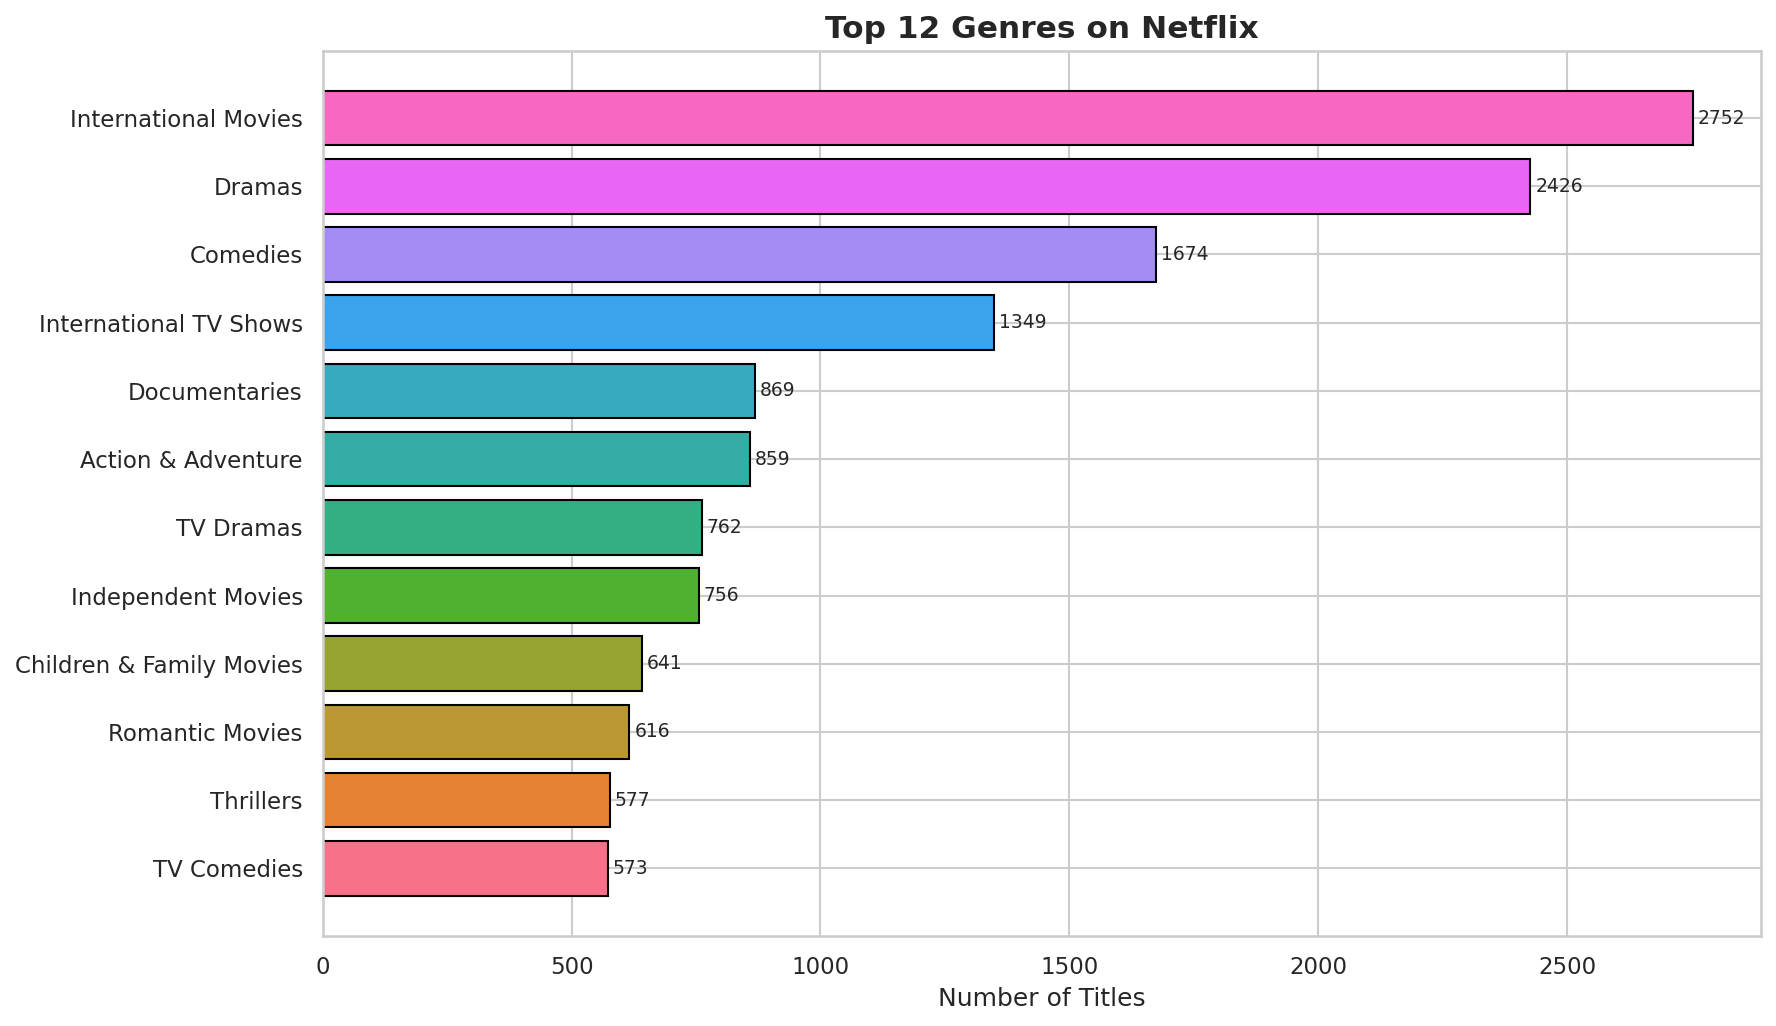

In [ ]:
# CELL 13 — CHART 5: Horizontal Bar — Top Genres
top12 = genres.value_counts().head(12)
fig, ax = plt.subplots(figsize=(12,7))
ax.barh(top12.index[::-1], top12.values[::-1],
        color=sns.color_palette("husl",12), edgecolor='black')
ax.set_title('Top 12 Genres on Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top12.values[::-1]):
    ax.text(v+10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_genres.png', dpi=150, bbox_inches='tight')
plt.show()


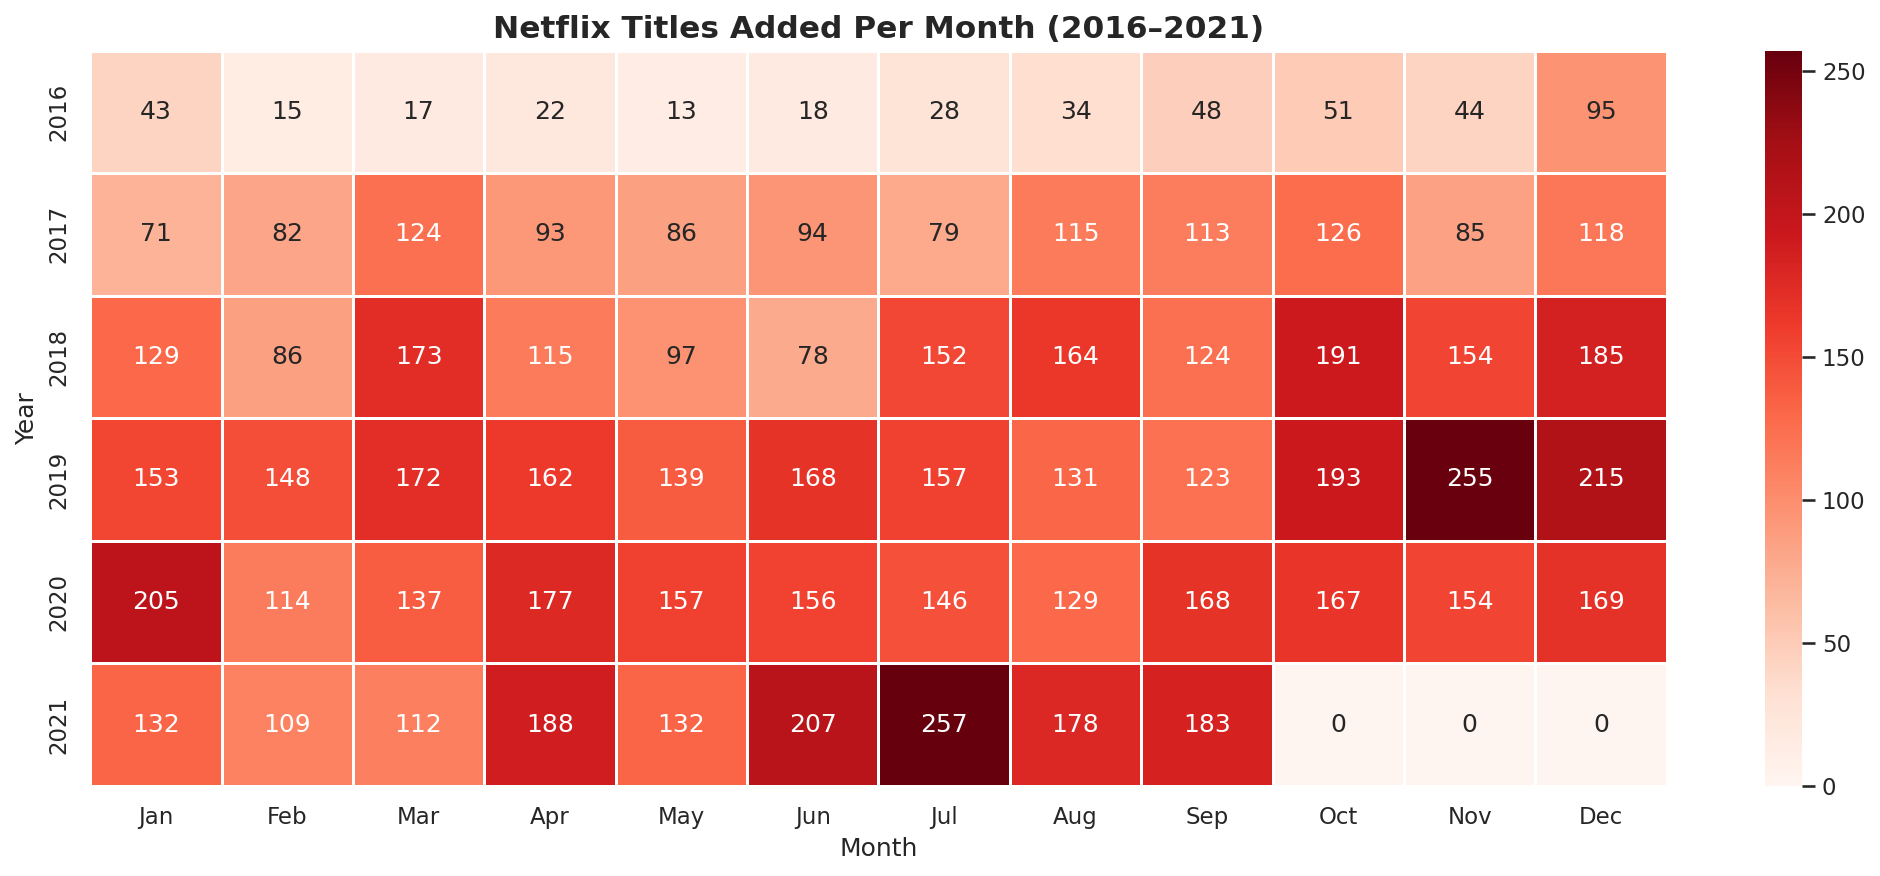

In [ ]:
# CELL 14 — CHART 6: Heatmap — Monthly Content Addition
heat = (df[df['year_added']>=2016]
        .groupby(['year_added','month_added']).size()
        .unstack(fill_value=0))
heat.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(heat.columns)]
fig, ax = plt.subplots(figsize=(14,6))
sns.heatmap(heat, annot=True, fmt='d', cmap='Reds', ax=ax, linewidths=0.5)
ax.set_title('Netflix Titles Added Per Month (2016–2021)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CELL 15 — FINAL STATS
print("="*50)
print("SUMMARY")
print("="*50)
print(f"Total Titles   : {len(df):,}")
print(f"Movies         : {len(df_movies):,}")
print(f"Countries      : {df['country'].str.split(',').str[0].str.strip().nunique()}")
print(f"Unique Genres  : {genres.nunique()}")
print(f"Avg Duration   : {df_movies['duration_mins'].mean():.0f} min")
print(f"Years Covered  : {df['year_added'].min()} to {df['year_added'].max()}")
print("All charts saved. Project 1 DONE.")


SUMMARY
Total Titles   : 8,793
Movies         : 6,126
Countries      : 87
Unique Genres  : 42
Avg Duration   : 100 min
Years Covered  : 2008 to 2021
All charts saved. Project 1 DONE.


## Insights Report

**Insight 1 — Movies Dominate Netflix**
Around 70% of Netflix content is Movies. However, TV Shows are growing
at a faster pace since 2016, showing Netflix is shifting strategy toward
long-form series to boost subscriber retention.

**Insight 2 — USA and India Lead Content**
The USA produces the most Netflix titles by far, followed by India.
This shows Netflix's dual strategy: dominate the American market while
capturing the massive Indian streaming audience.

**Insight 3 — Content Peaked in 2018–2019**
Netflix added the most content in 2018 and 2019 during its global
expansion to 130+ countries. The 2020 dip reflects COVID-19 halting
film and TV production worldwide.

**Insight 4 — Most Movies Are 80–110 Minutes**
The histogram shows Netflix movies cluster between 80–110 minutes —
standard cinema length. This helps recommendation systems filter by
user watch-time availability.

**Insight 5 — International Movies is the Largest Genre**
Surprisingly, "International Movies" is the top genre — larger than
Dramas or Comedies. Netflix is not a Hollywood-only platform; it is
a global content library spanning Korea, India, Spain and beyond.

**Most Surprising Finding:**
I expected English Drama to be the top genre. Instead, International
Movies topped the list. This completely changed my understanding of
Netflix's content strategy — non-English content is core, not niche.
─────────────────────────────────────────────────